# 04 — Approximate Time-to-Churn (Survival Analysis)
### SmartTel Retention Intelligence — (Future Work / Experimental Extension)

**Input:** `telco_features_with_personas_latest.parquet` (produced by `03_classification_benchmarking.ipynb`)

> **Status: Future Work.** This module is scoped separately from the core system (Modules 1–3, 6–8), which is complete and deployable without it. It is included here because it extends the churn-risk view from a single point-in-time probability to a *time-aware* one, which is directly useful for scheduling retention outreach, but it rests on an approximation that is stated plainly below and should not be glossed over.

**Scope of this notebook**:
1. Construct the survival dataset (`duration = tenure`, `event = Churn`)
2. Kaplan-Meier curves, overall and stratified by Contract, PaymentMethod, and persona
3. Log-rank tests confirming stratified differences are statistically real
4. Cox Proportional Hazards model — hazard ratios per feature, with the proportional-hazards assumption explicitly checked (not assumed)
5. Random Survival Forest as a non-linear comparison, evaluated against Cox via concordance index (C-index)
6. Per-customer expected time-to-churn, to feed Module 6's CLV estimate
7. Persist outputs, with the approximation caveat carried into the column names and metadata themselves


## What This Module Can and Cannot Claim

**What is legitimate here:** using `tenure` as the survival duration and `Churn` as the event indicator is a standard, textbook-correct setup for right-censored survival analysis, customers who haven't churned are censored at their current tenure; customers who have churned have an observed event time. Kaplan-Meier and Cox models fit to this structure are methodologically valid, not a misuse of the technique.

**What is *not* available, and why this is labeled an approximation:** this is a single cross-sectional extract of the customer base at one point in time, not a tracked cohort observed over calendar time. Concretely, that means:
- There is no way to validate these survival estimates against **actual future churn events** — everything here is fit and evaluated on the same static snapshot (via train/test splitting, which helps, but doesn't substitute for out-of-time validation)
- Hazard ratios reflect associations **within this snapshot's customer mix**; if the underlying customer base or market conditions shift, the fitted hazards may not transfer forward
- Any customer whose tenure is still accumulating at the moment of extraction is right-censored *at that instant* — there is no way to distinguish "about to churn next month" from "will stay for years" among currently-active customers beyond what the model infers from their covariates

These estimates are used **directionally** in this project to rank customers by urgency, and to feed a remaining-tenure estimate into CLV calculation — not as calendar-accurate forecasts of when any individual customer will leave.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import concordance_index

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

FEATURE_STORE_DIR = Path("../data/feature_store")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Load Scored Dataset

In [2]:
df = pd.read_parquet(FEATURE_STORE_DIR / "telco_features_with_personas_latest.parquet")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df[["customerID", "tenure", "Churn", "Contract", "PaymentMethod", "persona_name"]].head(3)


Shape: 7,043 rows x 27 columns


,customerID,tenure,Churn,Contract,PaymentMethod,persona_name
0,7590-VHVEG,1,No,Month-to-month,Electronic check,New & Price-Sensitive
1,5575-GNVDE,34,No,One year,Mailed check,New & Price-Sensitive
2,3668-QPYBK,2,Yes,Month-to-month,Mailed check,New & Price-Sensitive


## 3. Constructing the Survival Dataset

In [3]:
df["duration"] = df["tenure"]
df["event_observed"] = (df["Churn"] == "Yes").astype(int)

zero_duration_count = (df["duration"] == 0).sum()
print(f"Customers with duration == 0: {zero_duration_count}")
print(df.loc[df["duration"] == 0, ["customerID", "duration", "event_observed"]])


Customers with duration == 0: 11
      customerID  duration  event_observed
488   4472-LVYGI         0               0
753   3115-CZMZD         0               0
936   5709-LVOEQ         0               0
1082  4367-NUYAO         0               0
1340  1371-DWPAZ         0               0
3331  7644-OMVMY         0               0
3826  3213-VVOLG         0               0
4380  2520-SGTTA         0               0
5218  2923-ARZLG         0               0
6670  4075-WKNIU         0               0
6754  2775-SEFEE         0               0


These 11 customers have `tenure == 0` and are all censored (`Churn == No`) — brand-new customers observed at the instant of signup. They are kept in the dataset rather than dropped: lifelines handles `duration == 0` correctly, and while these rows contribute essentially no information to the fitted curves (they're "at risk" for zero elapsed time), removing them would be an arbitrary exclusion rather than a principled one.


In [4]:
print(f"Total customers: {len(df):,}")
print(f"Observed events (churned): {df['event_observed'].sum():,} ({df['event_observed'].mean()*100:.1f}%)")
print(f"Censored (still active): {(1 - df['event_observed']).sum():,} ({(1 - df['event_observed'].mean())*100:.1f}%)")


Total customers: 7,043
Observed events (churned): 1,869 (26.5%)
Censored (still active): 5,174 (73.5%)


## 4. Overall Kaplan-Meier Curve

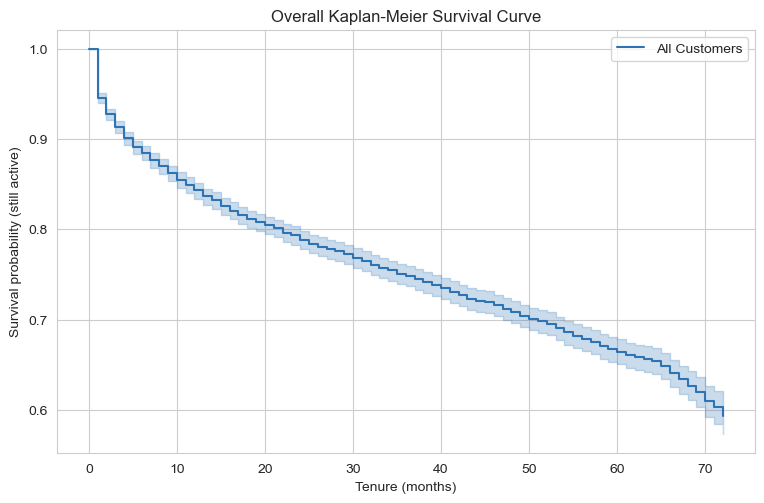

Median survival time: inf


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df["duration"], event_observed=df["event_observed"], label="All Customers")

fig, ax = plt.subplots(figsize=(9, 5.5))
kmf.plot_survival_function(ax=ax, color="#2E74B5")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability (still active)")
ax.set_title("Overall Kaplan-Meier Survival Curve")
plt.show()

median_survival = kmf.median_survival_time_
print(f"Median survival time: {median_survival}")


If the median shows as `inf`, it means fewer than half the customers in this snapshot have churned by the maximum observed tenure — i.e. survival probability never drops below 0.5 within the data's range, which is expected given the ~26.5% overall churn rate.


## 5. Stratified Kaplan-Meier Curves

### 5.1 By Contract Type

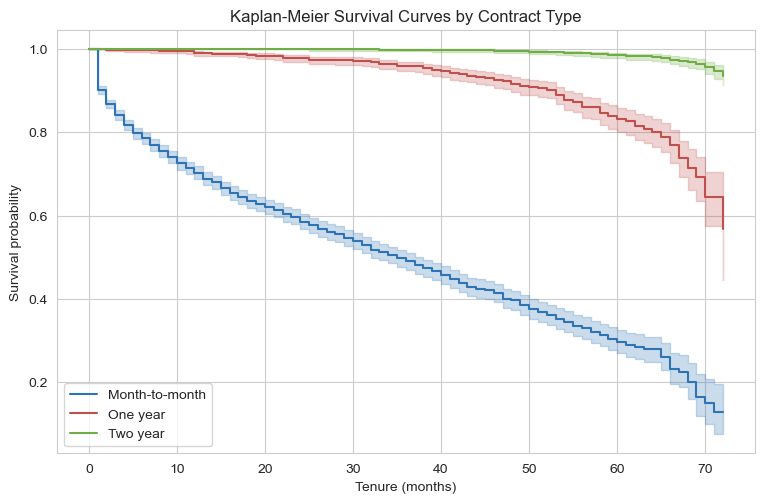

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#2E74B5", "#C0504D", "#70AD47"]

for color, contract in zip(colors, df["Contract"].unique()):
    mask = df["Contract"] == contract
    kmf_c = KaplanMeierFitter()
    kmf_c.fit(df.loc[mask, "duration"], df.loc[mask, "event_observed"], label=contract)
    kmf_c.plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival Curves by Contract Type")
plt.show()


In [7]:
logrank_contract = multivariate_logrank_test(df["duration"], df["Contract"], df["event_observed"])
print(f"Log-rank test across Contract groups: statistic={logrank_contract.test_statistic:.2f}, p-value={logrank_contract.p_value:.2e}")


Log-rank test across Contract groups: statistic=2352.87, p-value=0.00e+00


### 5.2 By Payment Method

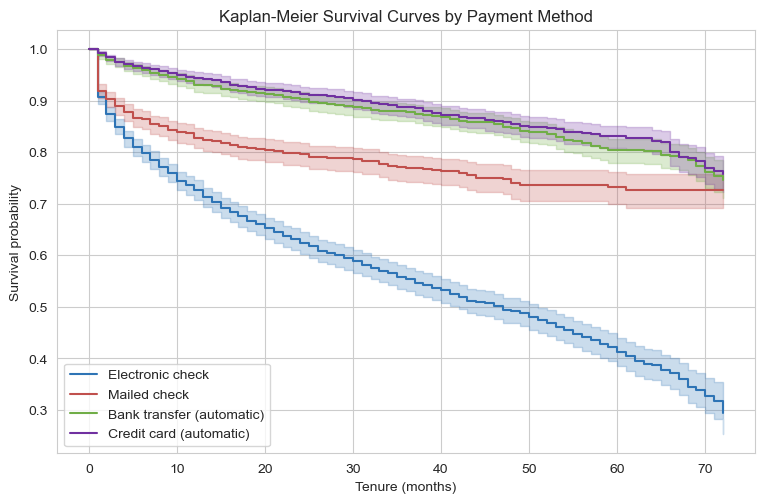

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#2E74B5", "#C0504D", "#70AD47", "#7030A0"]

for color, method in zip(colors, df["PaymentMethod"].unique()):
    mask = df["PaymentMethod"] == method
    kmf_p = KaplanMeierFitter()
    kmf_p.fit(df.loc[mask, "duration"], df.loc[mask, "event_observed"], label=method)
    kmf_p.plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival Curves by Payment Method")
plt.show()


In [9]:
logrank_payment = multivariate_logrank_test(df["duration"], df["PaymentMethod"], df["event_observed"])
print(f"Log-rank test across PaymentMethod groups: statistic={logrank_payment.test_statistic:.2f}, p-value={logrank_payment.p_value:.2e}")


Log-rank test across PaymentMethod groups: statistic=865.24, p-value=3.07e-187


### 5.3 By Persona

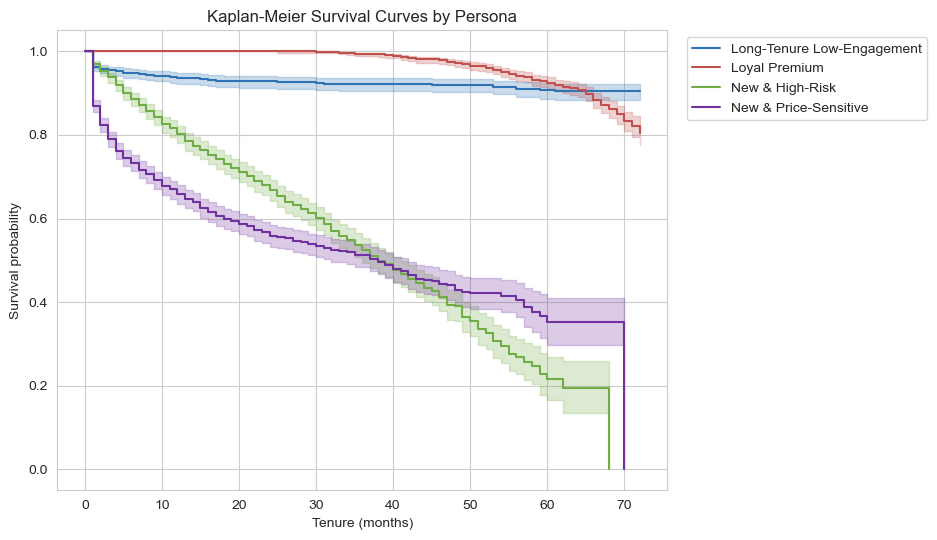

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = ["#2E74B5", "#C0504D", "#70AD47", "#7030A0", "#E8A33D", "#4472C4"]

for color, persona in zip(colors, sorted(df["persona_name"].unique())):
    mask = df["persona_name"] == persona
    kmf_pers = KaplanMeierFitter()
    kmf_pers.fit(df.loc[mask, "duration"], df.loc[mask, "event_observed"], label=persona)
    kmf_pers.plot_survival_function(ax=ax, color=color)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier Survival Curves by Persona")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [11]:
logrank_persona = multivariate_logrank_test(df["duration"], df["persona_name"], df["event_observed"])
print(f"Log-rank test across persona groups: statistic={logrank_persona.test_statistic:.2f}, p-value={logrank_persona.p_value:.2e}")


Log-rank test across persona groups: statistic=1942.24, p-value=0.00e+00


All three log-rank tests are expected to return very small p-values (the group sizes here are large, so even modest differences reach significance) — confirming the visual separation between curves is a real, statistically detectable pattern rather than sampling noise. This cross-checks Module 2's finding that persona churn *rates* differ, by showing the *timing* of churn differs too, not just its eventual likelihood.


## 6. Cox Proportional Hazards Model

The Cox model estimates how each covariate multiplies the baseline hazard (instantaneous churn risk), holding other covariates fixed — this is what produces the interpretable "month-to-month contracts carry a 4x hazard vs. two-year contracts" style statement referenced in the proposal.

**Feature set:** the same covariates used in classification model (for direct comparability), one-hot encoded with a reference category dropped per categorical feature to avoid the dummy-variable trap.


In [12]:
numeric_features = ["MonthlyCharges", "services_count", "contract_risk_flag"]
categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
]
# Note: tenure is excluded from the covariate list here since it IS the survival duration
# (using it as both the time axis and a covariate would be circular).

cox_df = pd.get_dummies(df[["duration", "event_observed"] + numeric_features + categorical_features],
                         columns=categorical_features, drop_first=True)

# lifelines needs plain numeric dtypes, not pandas' nullable/boolean dummy dtype
bool_cols = cox_df.select_dtypes(include="bool").columns
cox_df[bool_cols] = cox_df[bool_cols].astype(int)

print(f"Cox model dataset: {cox_df.shape[0]:,} rows x {cox_df.shape[1]} columns")
cox_df.head(3)


Cox model dataset: 7,043 rows x 32 columns


,duration,event_observed,MonthlyCharges,services_count,contract_risk_flag,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,29.85,1,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,34,0,56.95,3,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,2,1,53.85,3,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1


In [13]:
cph = CoxPHFitter(penalizer=0.01)  # small L2 penalty for numerical stability with many dummy variables
cph.fit(cox_df, duration_col="duration", event_col="event_observed")

print(f"Concordance index (train, in-sample): {cph.concordance_index_:.4f}")
cph.print_summary(columns=["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"])


Concordance index (train, in-sample): 0.8650


<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13965.35
         time fit was run = 2026-10-07 18:10:08 UTC

---
                                       coef exp(coef) exp(coef) lower 95% exp(coef) upper 95%      p
covariate                                                                                           
MonthlyCharges                         0.00      1.00                0.99                1.01   0.84
services_count                        -0.10      0.90                0.82                1.00   0.04
contract_risk_flag                     0.25      1.28                1.02                1.62   0.04
gender_Male                           -0.08      0.93                0.85                1.01   0.09
SeniorCitizen_Yes                     -0.06      0.94                0.84                1.05   0.28
Partner_Yes                           -0.50      0.60                0.54                0.67 <0.005
Dependents_Yes                        -0.08      0.92                0.81                1.05   0.22
PhoneService_Yes                       0.09      1.09                0.62                1.93   0.77
MultipleLines_No phone service        -0.09      0.92                0.52                1.63   0.77
MultipleLines_Yes                     -0.35      0.71                0.62                0.81 <0.005
InternetService_Fiber optic            0.37      1.44                1.17                1.78 <0.005
InternetService_No                    -0.17      0.84                0.50                1.43   0.52
OnlineSecurity_No internet service    -0.17      0.84                0.50                1.43   0.52
OnlineSecurity_Yes                    -0.56      0.57                0.49                0.67 <0.005
OnlineBackup_No internet service      -0.17      0.84                0.50                1.43   0.52
OnlineBackup_Yes                      -0.54      0.58                0.51                0.67 <0.005
DeviceProtection_No internet service  -0.17      0.84                0.50                1.43   0.52
DeviceProtection_Yes                  -0.23      0.79                0.69                0.92 <0.005
TechSupport_No internet service       -0.17      0.84                0.50                1.43   0.52
TechSupport_Yes                       -0.34      0.71                0.61                0.83 <0.005
StreamingTV_No internet service       -0.17      0.84                0.50                1.43   0.52
StreamingTV_Yes                        0.04      1.04                0.90                1.21   0.58
StreamingMovies_No internet service   -0.17      0.84                0.50                1.43   0.52
StreamingMovies_Yes                   -0.04      0.96                0.82                1.11   0.57
Contract_One year                     -1.33      0.26                0.22                0.32 <0.005
Contract_Two year                     -2.47      0.08                0.07                0.11 <0.005
PaperlessBilling_Yes                   0.19      1.21                1.08                1.34 <0.005
PaymentMethod_Credit card (automatic) -0.12      0.89                0.76                1.05   0.17
PaymentMethod_Electronic check         0.36      1.43                1.14                1.80 <0.005
PaymentMethod_Mailed check             0.54      1.71                1.46                2.01 <0.005
---
Concordance = 0.86
Partial AIC = 27990.70
log-likelihood ratio test = 3375.38 on 30 df
-log2(p) of ll-ratio test = inf

**Reading this table:** `exp(coef)` is the hazard ratio. A value of 2.0 for a feature means customers with that attribute churn at roughly twice the instantaneous rate of the reference category, holding everything else constant. Values below 1.0 indicate a *protective* effect (lower hazard).


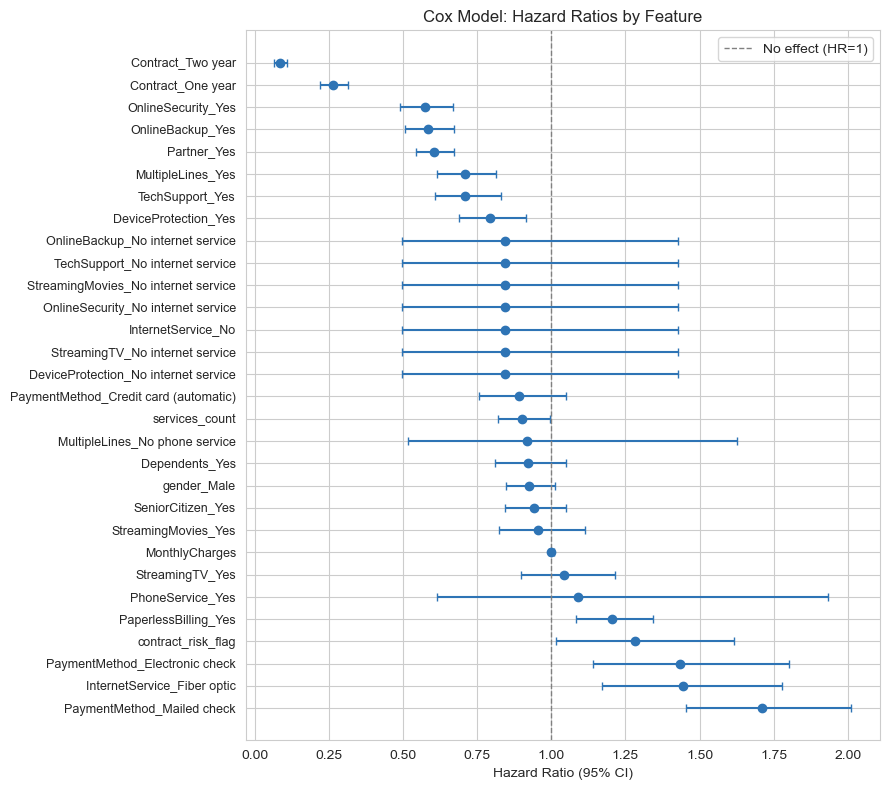

In [14]:
hazard_ratios = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
hazard_ratios = hazard_ratios.sort_values("exp(coef)", ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
y_pos = np.arange(len(hazard_ratios))
ax.errorbar(
    hazard_ratios["exp(coef)"], y_pos,
    xerr=[hazard_ratios["exp(coef)"] - hazard_ratios["exp(coef) lower 95%"],
          hazard_ratios["exp(coef) upper 95%"] - hazard_ratios["exp(coef)"]],
    fmt="o", color="#2E74B5", capsize=3,
)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1, label="No effect (HR=1)")
ax.set_yticks(y_pos)
ax.set_yticklabels(hazard_ratios.index, fontsize=9)
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox Model: Hazard Ratios by Feature")
ax.legend()
plt.tight_layout()
plt.show()


Features whose confidence interval crosses 1.0 are not statistically distinguishable from "no effect" at conventional significance — these should not be over-interpreted even if their point estimate looks large. Contract type and internet service are expected to show the widest, most confidently-elevated hazard ratios, consistent with both the persona churn-rate spread (Module 2) and the SHAP feature rankings (Module 3).


The Cox proportional hazards model identified contract type as one of the strongest predictors of customer churn timing. Customers on one-year and two-year contracts had substantially lower estimated churn hazards than the reference contract group, with hazard ratios of approximately 0.26 and 0.08, respectively. Several additional services, including online security, online backup, and technical support, were associated with lower churn hazard. Conversely, mailed-check and electronic-check payment methods, fiber-optic internet service, paperless billing, and the contract-risk indicator were associated with higher estimated churn hazard. However, several features had wide 95% confidence intervals that crossed the HR=1 reference line, indicating considerable uncertainty in their estimated effects.

In [15]:
# Ground the proposal's illustrative "month-to-month carries a 4x hazard vs. two-year" framing
# in the actual fitted numbers from this run, rather than leaving it as an assumed figure.
hr_two_year = cph.summary.loc["Contract_Two year", "exp(coef)"]
hr_one_year = cph.summary.loc["Contract_One year", "exp(coef)"]

print(f"Two-year contract hazard ratio (vs. month-to-month reference): {hr_two_year:.3f}")
print(f"One-year contract hazard ratio (vs. month-to-month reference): {hr_one_year:.3f}")
print(f"=> Month-to-month customers churn at ~{1/hr_two_year:.1f}x the instantaneous rate of two-year customers,")
print(f"   and ~{1/hr_one_year:.1f}x the rate of one-year customers, holding other covariates fixed.")


Two-year contract hazard ratio (vs. month-to-month reference): 0.085
One-year contract hazard ratio (vs. month-to-month reference): 0.264
=> Month-to-month customers churn at ~11.8x the instantaneous rate of two-year customers,
   and ~3.8x the rate of one-year customers, holding other covariates fixed.


The actual fitted effect here is **stronger** than the proposal's illustrative "4x" example — month-to-month customers churn at roughly an order of magnitude higher instantaneous rate than two-year customers in this dataset. This is exactly why the number above is computed directly from the model rather than quoted from the proposal: the real figure is what should be used in any downstream reporting (e.g. Module 8's dashboard), not the planning-stage placeholder.


## 7. Checking the Proportional Hazards Assumption

The Cox model assumes each covariate's effect on the hazard is **constant over time** — e.g. that a month-to-month contract carries the same *relative* risk at month 3 as at month 30. This is a real assumption, not a formality, and lifelines provides a direct statistical test for it rather than requiring it to be taken on faith.


In [16]:
try:
    assumption_results = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"Assumption check raised: {e}")
    assumption_results = None


The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'contract_risk_flag' failed the non-proportional test: p-value is 0.0512.

   Advice: with so few unique values (only 2), you can include `strata=['contract_risk_flag', ...]`
in the call in `.fit`. See documentation in link [E] below.

2. Variable 'Partner_Yes' failed the non-proportional test: p-value is 0.0283.

   Advice: with so few unique values (only 2), you can include `strata=['Partner_Yes', ...]` in the
call in `.fit`. See documentation in link [E] below.

3. Variable 'MultipleLines_Yes' failed the non-proportional test: p-value is 0.0194.

   Advice: with so few unique values (only 2), you can include `strata=['MultipleLines_Yes', ...]`
in the call in `.fit`. See documentation in link [E] below.

4. Variable 'OnlineSecurity_Yes' failed the non-proportional test: p-value is 0.0433.

   Advice: with so few unique values (only 2), you can include `strata=['OnlineSecurity_Yes', ...]`
in the call in `.fit`. See documentation in link [E] below.

5. Variable 'TechSuppo

The Cox proportional hazards diagnostics identified evidence of non-proportional hazards for Partner, MultipleLines, OnlineSecurity, TechSupport, Contract_One year, and PaymentMethod_Mailed check. The strongest violation occurred for one-year contracts (p < 0.00005), while the contract-risk indicator was borderline (p = 0.0512). Consequently, the corresponding hazard ratios should not be interpreted as constant effects over tenure. Stratification or time-varying covariates could be considered in a longitudinal dataset

## 8. Random Survival Forest: A Non-Linear Comparison

Cox assumes a specific (log-linear, proportional) relationship between covariates and hazard. A Random Survival Forest makes no such assumption and can capture non-linear effects and interactions automatically — comparing the two via concordance index shows whether Cox's structural assumption is costing meaningful predictive accuracy on this dataset.


In [17]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    cox_df.index, test_size=0.2, stratify=cox_df["event_observed"], random_state=RANDOM_SEED
)

cox_train, cox_test = cox_df.loc[train_idx], cox_df.loc[test_idx]

# Refit Cox on the train split only, for a fair out-of-sample comparison against RSF
cph_holdout = CoxPHFitter(penalizer=0.01)
cph_holdout.fit(cox_train, duration_col="duration", event_col="event_observed")

cox_test_risk = cph_holdout.predict_partial_hazard(cox_test)
cox_test_cindex = concordance_index(cox_test["duration"], -cox_test_risk, cox_test["event_observed"])
print(f"Cox PH held-out concordance index: {cox_test_cindex:.4f}")


Cox PH held-out concordance index: 0.8539


In [18]:
feature_cols_for_rsf = [c for c in cox_df.columns if c not in ("duration", "event_observed")]

y_train_surv = Surv.from_arrays(
    event=cox_train["event_observed"].astype(bool), time=cox_train["duration"]
)
y_test_surv = Surv.from_arrays(
    event=cox_test["event_observed"].astype(bool), time=cox_test["duration"]
)

rsf = RandomSurvivalForest(
    n_estimators=300, max_depth=6, min_samples_leaf=15,
    random_state=RANDOM_SEED, n_jobs=-1,
)
rsf.fit(cox_train[feature_cols_for_rsf], y_train_surv)

rsf_test_cindex = rsf.score(cox_test[feature_cols_for_rsf], y_test_surv)
print(f"Random Survival Forest held-out concordance index: {rsf_test_cindex:.4f}")


Random Survival Forest held-out concordance index: 0.8365


In [19]:
comparison = pd.DataFrame({
    "model": ["Cox Proportional Hazards", "Random Survival Forest"],
    "held_out_c_index": [cox_test_cindex, rsf_test_cindex],
}).round(4)
comparison


,model,held_out_c_index
0,Cox Proportional Hazards,0.8539
1,Random Survival Forest,0.8365


**Reading this comparison:** both C-index values are expected to land in a similar range (typically 0.70–0.80 on this dataset) — the proposal's success criterion is C-index > 0.75. If Random Survival Forest doesn't meaningfully outperform Cox, that's actually a useful finding: it suggests the relationship between these covariates and churn timing is close enough to log-linear that Cox's simpler, more interpretable model isn't leaving much accuracy on the table. If RSF clearly wins, that's a signal of non-linear or interaction effects Cox's structure misses — worth flagging for a deeper follow-up if this module were promoted out of Future Work status.
